In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Vamos a hacer un estudio del tamaño aparente del sol de manera experimental, tal como aparece en la guía del curso "/workspaces/IntroduccionAstronomiaPractica/GuiaCurso.pdf".

Utilizaremos la fórmula 

$$\theta = \omega t$$

Sabemos que $\omega = 15°/\text{h}$, y hemos tomado datos para $t$, que se encuentran almacenados en "/workspaces/IntroduccionAstronomiaPractica/ProyectoTamañoAngularAparente/DatosTiempo.dat"

## Propagación de errores

Para una función de una sola variable como $\theta = \omega t$, donde $\omega$ es una constante, la propagación de la incertidumbre se obtiene mediante el cálculo diferencial.

### Formulación matemática
La incertidumbre absoluta $\delta \theta$ se define como el producto de la derivada de la función por la incertidumbre de la variable medida:

$$\delta \theta = \left| \frac{d\theta}{dt} \right| \delta t$$

Como la derivada de $\omega t$ respecto a $t$ es simplemente $\omega$, la expresión se simplifica a:
$$\delta \theta = \omega \cdot \delta t$$

### Aplicación para $\delta t = \pm 15$ seg
El error en el cálculo del tamaño angular será:

$$\mathbf{\delta \theta = \omega \cdot 15 \text{ s}}$$

Esto significa que la **incertidumbre absoluta del ángulo** es igual a la velocidad angular multiplicada.

## Carga de datos y parámetros físicos

En este análisis trabajaremos con las mediciones de tiempo `t` (en minutos) almacenadas en `DatosTiempo.dat`.

Parámetros del modelo:

- $\omega = 15^\circ/\mathrm{h} = 0.25^\circ/\mathrm{min}$
- Incertidumbre instrumental estimada: $\delta t = 15\,\mathrm{s} = 0.25\,\mathrm{min}$
- Relación física: $\theta = \omega t$

In [3]:
# Carga de datos
from pathlib import Path

base_path = Path('/workspaces/IntroduccionAstronomiaPractica/ProyectoTamañoAngularAparente')
dat_path = base_path / 'DatosTiempo.dat'
xlsx_path = base_path / 'DatosTiempo.xlsx'

# Intento principal: archivo .dat de una columna
if dat_path.exists():
    t = pd.read_csv(dat_path, header=None, comment='#').squeeze('columns').astype(float)
else:
    # Respaldo: primera columna numérica del .xlsx
    df_xlsx = pd.read_excel(xlsx_path)
    num_cols = df_xlsx.select_dtypes(include=[np.number]).columns
    if len(num_cols) == 0:
        raise ValueError('No se encontraron columnas numéricas en DatosTiempo.xlsx')
    t = df_xlsx[num_cols[0]].dropna().astype(float)

t = t.dropna().reset_index(drop=True)
n = len(t)

# Constantes del experimento
omega_deg_per_min = 15 / 60   # 0.25 deg/min
delta_t_min = 15 / 60         # 0.25 min

df = pd.DataFrame({
    'medicion': np.arange(1, n + 1),
    't_min': t,
})

df.head(), n

(   medicion     t_min
 0         1  6.533333
 1         2  5.333333
 2         3  6.800000
 3         4  4.183333
 4         5  4.166667,
 34)

## Análisis estadístico e incertidumbre

Calculamos estadísticos descriptivos para `t` y luego propagamos la incertidumbre hacia el ángulo aparente usando:

$$\theta = \omega t, \qquad \delta\theta = \omega\,\delta t$$

También se reporta un intervalo de confianza del 95% para la media de $t$ (aproximación normal).

In [4]:
# Estadística descriptiva y propagación de incertidumbre
mean_t = df['t_min'].mean()
median_t = df['t_min'].median()
std_t = df['t_min'].std(ddof=1)
var_t = df['t_min'].var(ddof=1)
sem_t = std_t / np.sqrt(n)
q1_t = df['t_min'].quantile(0.25)
q3_t = df['t_min'].quantile(0.75)
iqr_t = q3_t - q1_t

# IC 95% aproximado con z=1.96
ci95_low_t = mean_t - 1.96 * sem_t
ci95_high_t = mean_t + 1.96 * sem_t

# Magnitud angular por medición y su incertidumbre instrumental
df['theta_deg'] = omega_deg_per_min * df['t_min']
df['delta_theta_deg'] = omega_deg_per_min * delta_t_min

theta_mean = df['theta_deg'].mean()
theta_std = df['theta_deg'].std(ddof=1)
theta_sem = theta_std / np.sqrt(n)
ci95_low_theta = theta_mean - 1.96 * theta_sem
ci95_high_theta = theta_mean + 1.96 * theta_sem

resumen = pd.DataFrame({
    'magnitud': [
        'n',
        'media_t_min', 'mediana_t_min', 'std_t_min', 'var_t_min2', 'sem_t_min',
        'q1_t_min', 'q3_t_min', 'iqr_t_min', 'IC95_t_min_inferior', 'IC95_t_min_superior',
        'delta_t_min',
        'media_theta_deg', 'std_theta_deg', 'sem_theta_deg',
        'IC95_theta_deg_inferior', 'IC95_theta_deg_superior',
        'delta_theta_deg'
    ],
    'valor': [
        n,
        mean_t, median_t, std_t, var_t, sem_t,
        q1_t, q3_t, iqr_t, ci95_low_t, ci95_high_t,
        delta_t_min,
        theta_mean, theta_std, theta_sem,
        ci95_low_theta, ci95_high_theta,
        omega_deg_per_min * delta_t_min
    ]
})

resumen

,magnitud,valor
0,n,34.000000
1,media_t_min,3.282595
2,mediana_t_min,2.941455
3,std_t_min,1.135220
4,var_t_min2,1.288723
5,sem_t_min,0.194689
6,q1_t_min,2.676754
7,q3_t_min,3.645833
8,iqr_t_min,0.969080
9,IC95_t_min_inferior,2.901005


## Gráficos relevantes (con barras de error)

Se muestran tres vistas complementarias:

1. Serie de mediciones de `t` con barras de error $\pm\delta t$.
2. Histograma de `t` para visualizar distribución y dispersión.
3. Serie de $\theta$ con barras de error $\pm\delta\theta$ y línea de promedio.

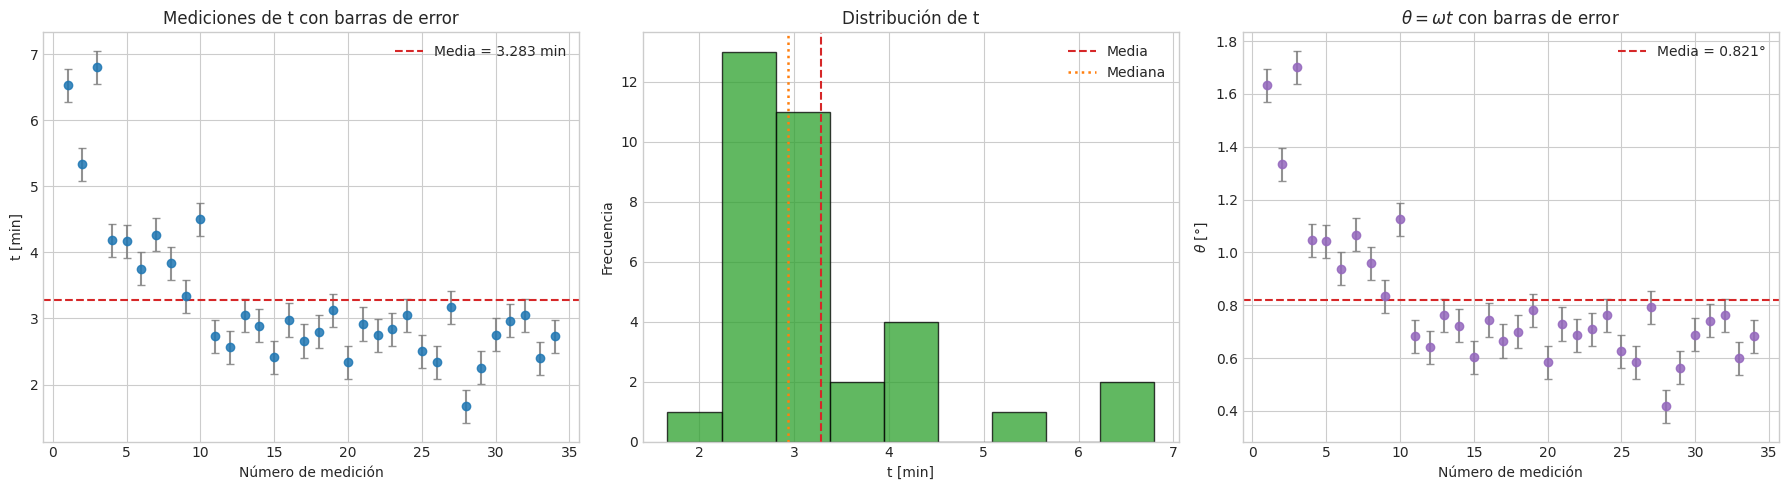

In [5]:
# Visualizaciones con barras de error
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Serie temporal de t con incertidumbre instrumental
axes[0].errorbar(
    df['medicion'],
    df['t_min'],
    yerr=delta_t_min,
    fmt='o',
    capsize=3,
    alpha=0.85,
    color='tab:blue',
    ecolor='tab:gray'
)
axes[0].axhline(mean_t, color='tab:red', linestyle='--', linewidth=1.5, label=f'Media = {mean_t:.3f} min')
axes[0].set_title('Mediciones de t con barras de error')
axes[0].set_xlabel('Número de medición')
axes[0].set_ylabel('t [min]')
axes[0].legend()

# 2) Histograma de t
axes[1].hist(df['t_min'], bins='auto', color='tab:green', alpha=0.75, edgecolor='black')
axes[1].axvline(mean_t, color='tab:red', linestyle='--', linewidth=1.5, label='Media')
axes[1].axvline(median_t, color='tab:orange', linestyle=':', linewidth=1.8, label='Mediana')
axes[1].set_title('Distribución de t')
axes[1].set_xlabel('t [min]')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3) Theta con propagación de incertidumbre
axes[2].errorbar(
    df['medicion'],
    df['theta_deg'],
    yerr=df['delta_theta_deg'],
    fmt='o',
    capsize=3,
    alpha=0.85,
    color='tab:purple',
    ecolor='tab:gray'
)
axes[2].axhline(theta_mean, color='tab:red', linestyle='--', linewidth=1.5, label=f'Media = {theta_mean:.3f}°')
axes[2].set_title(r'$\theta = \omega t$ con barras de error')
axes[2].set_xlabel('Número de medición')
axes[2].set_ylabel(r'$\theta$ [°]')
axes[2].legend()

plt.tight_layout()
plt.show()

# Gráfico interactivo opcional (plotly)
fig_go = go.Figure()
fig_go.add_trace(go.Scatter(
    x=df['medicion'],
    y=df['theta_deg'],
    mode='markers',
    name='theta [°]',
    error_y=dict(type='data', array=df['delta_theta_deg'], visible=True)
))
fig_go.add_hline(y=theta_mean, line_dash='dash', annotation_text=f"Media = {theta_mean:.3f}°")
fig_go.update_layout(
    title='Tamaño angular aparente estimado por medición',
    xaxis_title='Número de medición',
    yaxis_title='theta [°]',
    template='plotly_white'
)
fig_go.show()